# CIFAR-10: Trees, Forests and Boosting


**Goals of this Colab Notebook:**
*  See bagging and boosting in action on a more complicated example

In [ ]:
# Some useful libraries
import numpy as np
from numpy.random import default_rng

#Pandas for data structure and analysis tools
import pandas as pd

#seaborn and matplotlib for plotting
import seaborn as sns
import matplotlib.pyplot as plt

#for nice vector graphics
%matplotlib inline

#from IPython.display import set_matplotlib_formats
#set_matplotlib_formats('png', 'pdf')

np.random.seed(42) # Fixed seed for reproducibility
rng = default_rng(42)

In [ ]:
import numpy as np
from sklearn import tree
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import check_random_state


### Load CIFAR-10



In [ ]:
from keras.datasets import cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
labels = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step


In [ ]:
# Reshape X
X_tr = X_train.reshape((X_train.shape[0], -1))
print('This is now the shape of X:',X_tr.shape)

This is now the shape of X: (50000, 3072)


In [ ]:
# There are 50,000 data points. Let's just pick a subset of them.
# You are welcome to use more of them to see if there's a big difference.
# The loader already shuffled, so it's safe to just pick the first ones.
N_tr = 5000
train_samples = N_tr
X_str = X_tr[:N_tr,:]
y_str = y_train[:N_tr]
# check size
X_str.shape

(5000, 3072)

In [ ]:
# reshape the testing points
X_t = X_test.reshape((X_test.shape[0], -1))

training_scores = []
testing_scores = []
depth_values = range(15)
for depth in depth_values:
    dt = tree.DecisionTreeClassifier(max_depth=depth+1, criterion='gini')
    dt.fit(X_str,y_str)
    train_score = dt.score(X_str,y_str)
    test_score = dt.score(X_t, y_test)
    training_scores.append(train_score)
    testing_scores.append(test_score)

In [ ]:
print('These are the training scores:',training_scores)
print('These are the testing scores:',testing_scores)

These are the training scores: [0.1658, 0.2064, 0.256, 0.2832, 0.3224, 0.3644, 0.4196, 0.4794, 0.555, 0.6338, 0.7054, 0.7794, 0.8426, 0.8896, 0.9276]
These are the testing scores: [0.1563, 0.1942, 0.2339, 0.2363, 0.2461, 0.2427, 0.2411, 0.237, 0.2367, 0.2368, 0.2386, 0.2337, 0.2308, 0.2321, 0.2304]


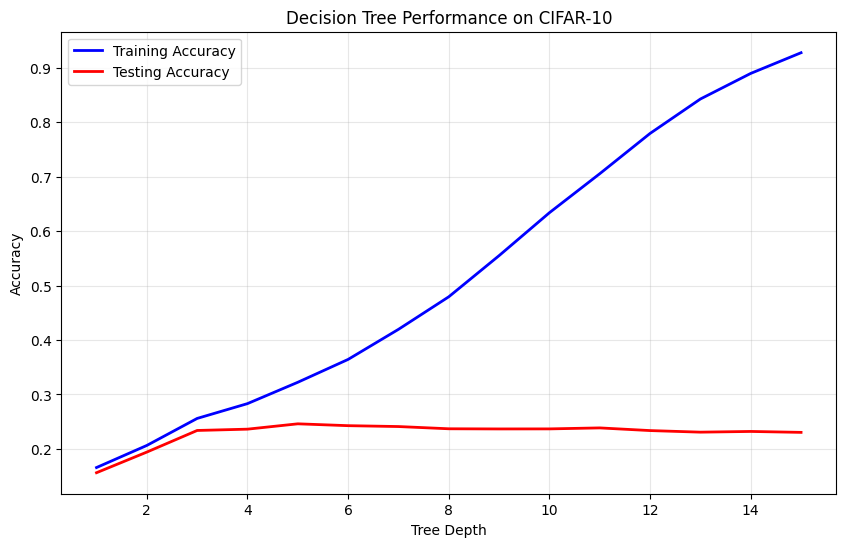

Best testing accuracy with decision trees: 0.2461
Best training accuracy with decision trees: 0.9276


In [ ]:
# Plot the decision tree results
plt.figure(figsize=(10, 6))
plt.plot(range(1, 16), training_scores, 'b-', label='Training Accuracy', linewidth=2)
plt.plot(range(1, 16), testing_scores, 'r-', label='Testing Accuracy', linewidth=2)
plt.xlabel('Tree Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree Performance on CIFAR-10')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Best testing accuracy with decision trees: {max(testing_scores):.4f}")
print(f"Best training accuracy with decision trees: {max(training_scores):.4f}")


## Random Forest Experiments

Now let's try Random Forest with different numbers of estimators (k=5, 10, 50, 100) and fixed depth=10 to see if we can improve upon the single decision tree performance.


In [ ]:
# Import Random Forest
from sklearn.ensemble import RandomForestClassifier

# Random Forest experiments with k=5, 10, 50, 100 and depth=10
n_estimators_list = [1, 5, 10, 50, 100]
rf_training_scores = []
rf_testing_scores = []

print("Training Random Forest models...")
for n_est in n_estimators_list:
    print(f"Training Random Forest with {n_est} estimators...")
    rf = RandomForestClassifier(n_estimators=n_est, max_depth=15, random_state=42, n_jobs=-1)
    rf.fit(X_str, y_str.ravel())  # ravel() to flatten the labels

    train_score = rf.score(X_str, y_str.ravel())
    test_score = rf.score(X_t, y_test.ravel())

    rf_training_scores.append(train_score)
    rf_testing_scores.append(test_score)

    print(f"  Training accuracy: {train_score:.4f}")
    print(f"  Testing accuracy: {test_score:.4f}")
    print()

print("Random Forest Results:")
for i, n_est in enumerate(n_estimators_list):
    print(f"k={n_est}: Train={rf_training_scores[i]:.4f}, Test={rf_testing_scores[i]:.4f}")


Training Random Forest models...
Training Random Forest with 1 estimators...
  Training accuracy: 0.6684
  Testing accuracy: 0.2084

Training Random Forest with 5 estimators...
  Training accuracy: 0.9148
  Testing accuracy: 0.2560

Training Random Forest with 10 estimators...
  Training accuracy: 0.9834
  Testing accuracy: 0.2954

Training Random Forest with 50 estimators...
  Training accuracy: 0.9996
  Testing accuracy: 0.3772

Training Random Forest with 100 estimators...
  Training accuracy: 1.0000
  Testing accuracy: 0.3911

Random Forest Results:
k=1: Train=0.6684, Test=0.2084
k=5: Train=0.9148, Test=0.2560
k=10: Train=0.9834, Test=0.2954
k=50: Train=0.9996, Test=0.3772
k=100: Train=1.0000, Test=0.3911


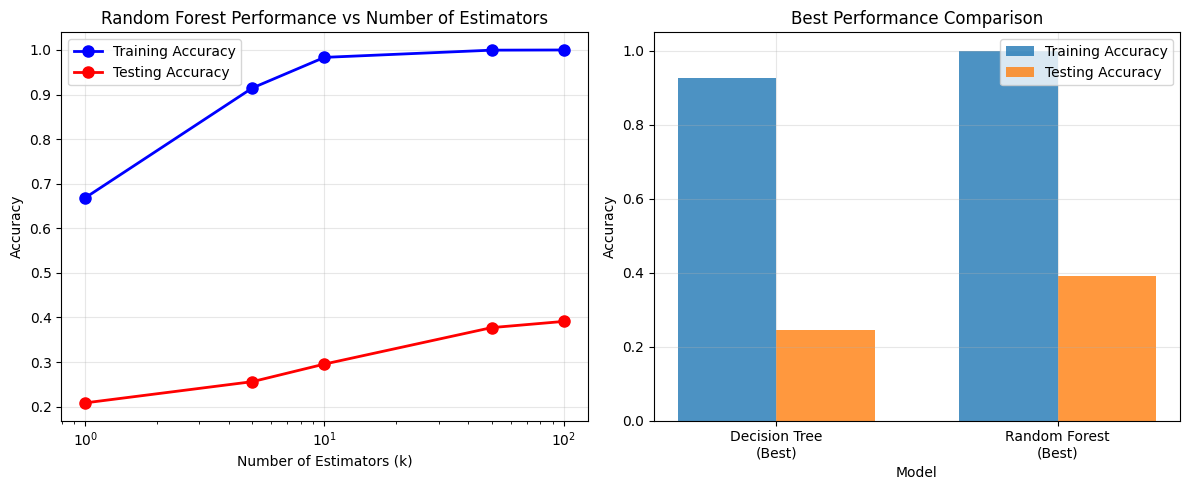


Improvement Summary:
Best Decision Tree Test Accuracy: 0.2461
Best Random Forest Test Accuracy: 0.3911
Improvement: 0.1450 (58.9%)


In [ ]:
# Plot Random Forest results
plt.figure(figsize=(12, 5))

# Subplot 1: Random Forest performance vs number of estimators
plt.subplot(1, 2, 1)
plt.plot(n_estimators_list, rf_training_scores, 'b-o', label='Training Accuracy', linewidth=2, markersize=8)
plt.plot(n_estimators_list, rf_testing_scores, 'r-o', label='Testing Accuracy', linewidth=2, markersize=8)
plt.xlabel('Number of Estimators (k)')
plt.ylabel('Accuracy')
plt.title('Random Forest Performance vs Number of Estimators')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xscale('log')

# Subplot 2: Comparison with best decision tree
plt.subplot(1, 2, 2)
best_dt_test = max(testing_scores)
best_rf_test = max(rf_testing_scores)
best_dt_train = max(training_scores)
best_rf_train = max(rf_training_scores)

models = ['Decision Tree\n(Best)', 'Random Forest\n(Best)']
test_accs = [best_dt_test, best_rf_test]
train_accs = [best_dt_train, best_rf_train]

x = np.arange(len(models))
width = 0.35

plt.bar(x - width/2, train_accs, width, label='Training Accuracy', alpha=0.8)
plt.bar(x + width/2, test_accs, width, label='Testing Accuracy', alpha=0.8)
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Best Performance Comparison')
plt.xticks(x, models)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nImprovement Summary:")
print(f"Best Decision Tree Test Accuracy: {best_dt_test:.4f}")
print(f"Best Random Forest Test Accuracy: {best_rf_test:.4f}")
print(f"Improvement: {best_rf_test - best_dt_test:.4f} ({((best_rf_test - best_dt_test) / best_dt_test * 100):.1f}%)")


## XGBoost Experiments

Now let's try XGBoost with different numbers of estimators (k=5, 10, 50, 100, 200) and fixed depth=3 to see if gradient boosting can further improve performance.


In [ ]:
# Import XGBoost
try:
    import xgboost as xgb
    print("XGBoost imported successfully!")
except ImportError:
    print("XGBoost not installed. Installing...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost"])
    import xgboost as xgb
    print("XGBoost installed and imported successfully!")

# XGBoost experiments with k=5, 10, 50, 100, 200 and depth=3
n_estimators_xgb = [5, 10, 50, 100, 200]
xgb_training_scores = []
xgb_testing_scores = []

print("Training XGBoost models...")
for n_est in n_estimators_xgb:
    print(f"Training XGBoost with {n_est} estimators...")
    xgb_model = xgb.XGBClassifier(
        n_estimators=n_est,
        max_depth=3,
        random_state=42,
        n_jobs=-1,
        verbosity=0  # Suppress output
    )
    xgb_model.fit(X_str, y_str.ravel())

    train_score = xgb_model.score(X_str, y_str.ravel())
    test_score = xgb_model.score(X_t, y_test.ravel())

    xgb_training_scores.append(train_score)
    xgb_testing_scores.append(test_score)

    print(f"  Training accuracy: {train_score:.4f}")
    print(f"  Testing accuracy: {test_score:.4f}")
    print()

print("XGBoost Results:")
for i, n_est in enumerate(n_estimators_xgb):
    print(f"k={n_est}: Train={xgb_training_scores[i]:.4f}, Test={xgb_testing_scores[i]:.4f}")


XGBoost imported successfully!
Training XGBoost models...
Training XGBoost with 5 estimators...
  Training accuracy: 0.4948
  Testing accuracy: 0.3284

Training XGBoost with 10 estimators...
  Training accuracy: 0.5824
  Testing accuracy: 0.3590

Training XGBoost with 50 estimators...
  Training accuracy: 0.9056
  Testing accuracy: 0.4187

Training XGBoost with 100 estimators...
  Training accuracy: 0.9954
  Testing accuracy: 0.4293

Training XGBoost with 200 estimators...
  Training accuracy: 1.0000
  Testing accuracy: 0.4457

XGBoost Results:
k=5: Train=0.4948, Test=0.3284
k=10: Train=0.5824, Test=0.3590
k=50: Train=0.9056, Test=0.4187
k=100: Train=0.9954, Test=0.4293
k=200: Train=1.0000, Test=0.4457


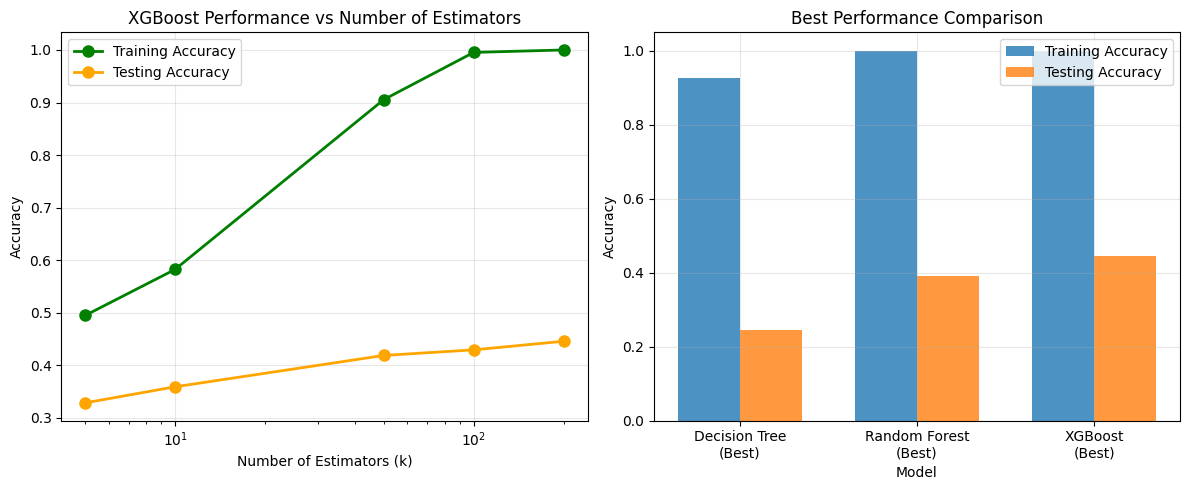


Final Performance Summary:
Best Decision Tree Test Accuracy: 0.2461
Best Random Forest Test Accuracy: 0.3911
Best XGBoost Test Accuracy: 0.4457

Improvements over Decision Tree:
Random Forest: 0.1450 (58.9%)
XGBoost: 0.1996 (81.1%)
XGBoost vs Random Forest: 0.0546 (14.0%)


In [ ]:
# Plot XGBoost results
plt.figure(figsize=(12, 5))

# Subplot 1: XGBoost performance vs number of estimators
plt.subplot(1, 2, 1)
plt.plot(n_estimators_xgb, xgb_training_scores, 'g-o', label='Training Accuracy', linewidth=2, markersize=8)
plt.plot(n_estimators_xgb, xgb_testing_scores, 'orange', marker='o', label='Testing Accuracy', linewidth=2, markersize=8)
plt.xlabel('Number of Estimators (k)')
plt.ylabel('Accuracy')
plt.title('XGBoost Performance vs Number of Estimators')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xscale('log')

# Subplot 2: Comparison with best models
plt.subplot(1, 2, 2)
best_dt_test = max(testing_scores)
best_rf_test = max(rf_testing_scores)
best_xgb_test = max(xgb_testing_scores)
best_dt_train = max(training_scores)
best_rf_train = max(rf_training_scores)
best_xgb_train = max(xgb_training_scores)

models = ['Decision Tree\n(Best)', 'Random Forest\n(Best)', 'XGBoost\n(Best)']
test_accs = [best_dt_test, best_rf_test, best_xgb_test]
train_accs = [best_dt_train, best_rf_train, best_xgb_train]

x = np.arange(len(models))
width = 0.35

plt.bar(x - width/2, train_accs, width, label='Training Accuracy', alpha=0.8)
plt.bar(x + width/2, test_accs, width, label='Testing Accuracy', alpha=0.8)
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Best Performance Comparison')
plt.xticks(x, models)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal Performance Summary:")
print(f"Best Decision Tree Test Accuracy: {best_dt_test:.4f}")
print(f"Best Random Forest Test Accuracy: {best_rf_test:.4f}")
print(f"Best XGBoost Test Accuracy: {best_xgb_test:.4f}")
print(f"\nImprovements over Decision Tree:")
print(f"Random Forest: {best_rf_test - best_dt_test:.4f} ({((best_rf_test - best_dt_test) / best_dt_test * 100):.1f}%)")
print(f"XGBoost: {best_xgb_test - best_dt_test:.4f} ({((best_xgb_test - best_dt_test) / best_dt_test * 100):.1f}%)")
print(f"XGBoost vs Random Forest: {best_xgb_test - best_rf_test:.4f} ({((best_xgb_test - best_rf_test) / best_rf_test * 100):.1f}%)")


## Comprehensive Comparison

Let's create a final comprehensive plot showing all results together.


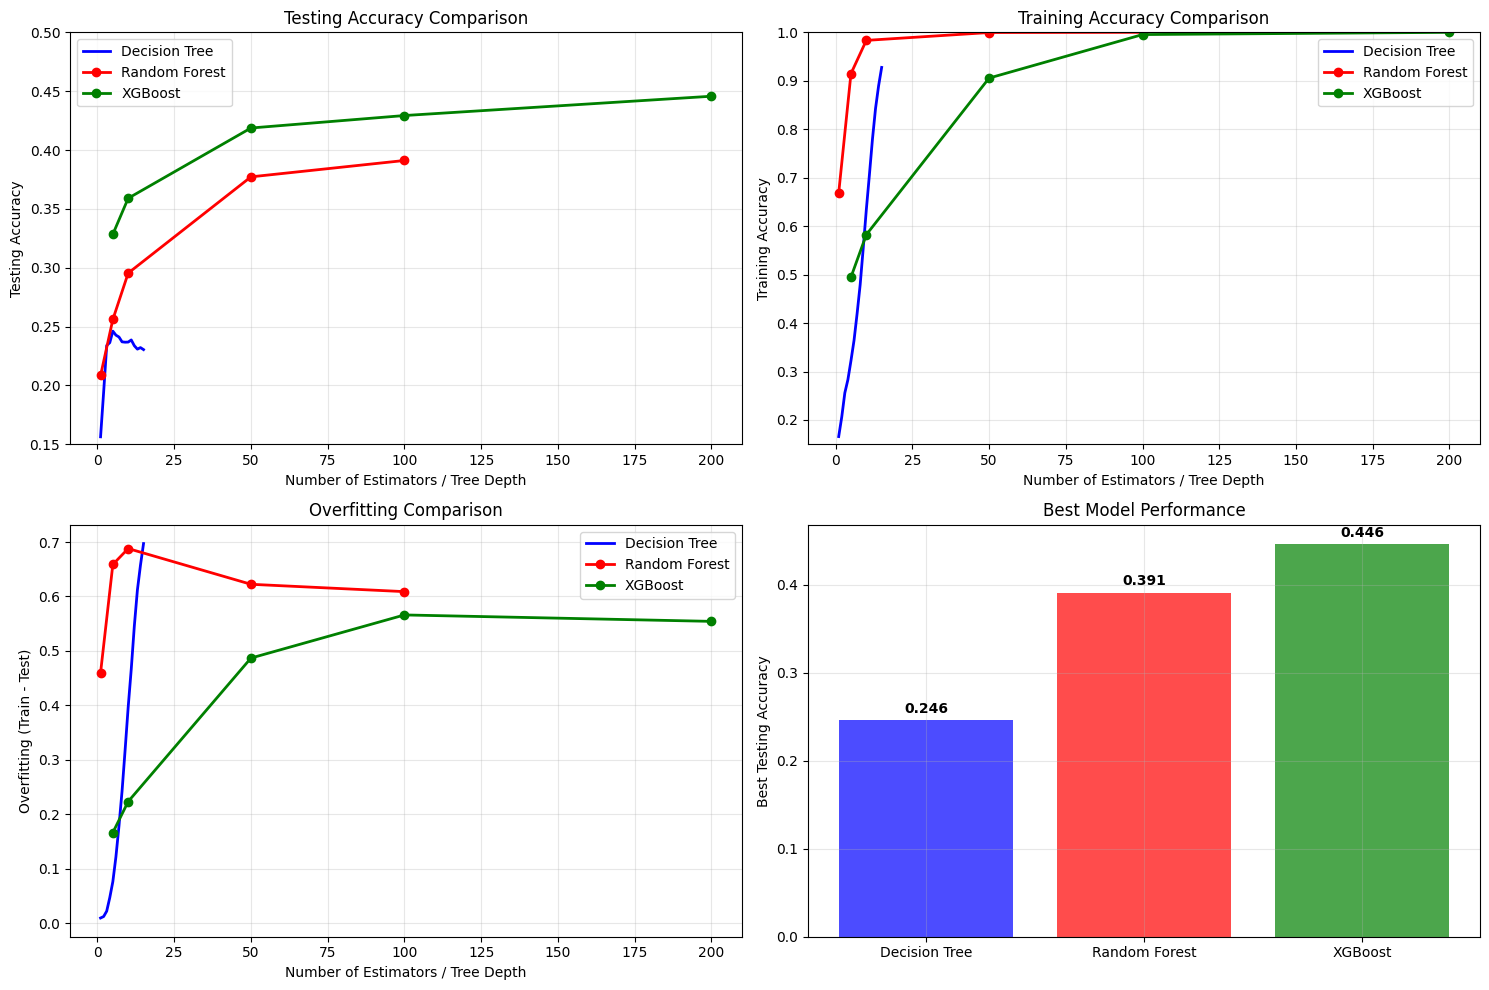


FINAL RESULTS SUMMARY
Model                Best Test Acc   Best Train Acc  Overfitting 
------------------------------------------------------------
Decision Tree        0.2461          0.9276          0.6815      
Random Forest        0.3911          1.0000          0.6089      
XGBoost              0.4457          1.0000          0.5543      


In [ ]:
# Comprehensive comparison plot
plt.figure(figsize=(15, 10))

# Plot 1: All testing accuracies comparison
plt.subplot(2, 2, 1)
plt.plot(range(1, 16), testing_scores, 'b-', label='Decision Tree', linewidth=2)
plt.plot(n_estimators_list, rf_testing_scores, 'r-o', label='Random Forest', linewidth=2, markersize=6)
plt.plot(n_estimators_xgb, xgb_testing_scores, 'g-o', label='XGBoost', linewidth=2, markersize=6)
plt.xlabel('Number of Estimators / Tree Depth')
plt.ylabel('Testing Accuracy')
plt.title('Testing Accuracy Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0.15, 0.5)

# Plot 2: All training accuracies comparison
plt.subplot(2, 2, 2)
plt.plot(range(1, 16), training_scores, 'b-', label='Decision Tree', linewidth=2)
plt.plot(n_estimators_list, rf_training_scores, 'r-o', label='Random Forest', linewidth=2, markersize=6)
plt.plot(n_estimators_xgb, xgb_training_scores, 'g-o', label='XGBoost', linewidth=2, markersize=6)
plt.xlabel('Number of Estimators / Tree Depth')
plt.ylabel('Training Accuracy')
plt.title('Training Accuracy Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0.15, 1.0)

# Plot 3: Overfitting comparison (Train - Test)
plt.subplot(2, 2, 3)
dt_overfitting = [t - s for t, s in zip(training_scores, testing_scores)]
rf_overfitting = [t - s for t, s in zip(rf_training_scores, rf_testing_scores)]
xgb_overfitting = [t - s for t, s in zip(xgb_training_scores, xgb_testing_scores)]

plt.plot(range(1, 16), dt_overfitting, 'b-', label='Decision Tree', linewidth=2)
plt.plot(n_estimators_list, rf_overfitting, 'r-o', label='Random Forest', linewidth=2, markersize=6)
plt.plot(n_estimators_xgb, xgb_overfitting, 'g-o', label='XGBoost', linewidth=2, markersize=6)
plt.xlabel('Number of Estimators / Tree Depth')
plt.ylabel('Overfitting (Train - Test)')
plt.title('Overfitting Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 4: Best model comparison
plt.subplot(2, 2, 4)
models = ['Decision Tree', 'Random Forest', 'XGBoost']
best_test_accs = [best_dt_test, best_rf_test, best_xgb_test]
colors = ['blue', 'red', 'green']

bars = plt.bar(models, best_test_accs, color=colors, alpha=0.7)
plt.ylabel('Best Testing Accuracy')
plt.title('Best Model Performance')
plt.grid(True, alpha=0.3)

# Add value labels on bars
for bar, acc in zip(bars, best_test_accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Summary table
print("\n" + "="*60)
print("FINAL RESULTS SUMMARY")
print("="*60)
print(f"{'Model':<20} {'Best Test Acc':<15} {'Best Train Acc':<15} {'Overfitting':<12}")
print("-"*60)
print(f"{'Decision Tree':<20} {best_dt_test:<15.4f} {best_dt_train:<15.4f} {best_dt_train-best_dt_test:<12.4f}")
print(f"{'Random Forest':<20} {best_rf_test:<15.4f} {best_rf_train:<15.4f} {best_rf_train-best_rf_test:<12.4f}")
print(f"{'XGBoost':<20} {best_xgb_test:<15.4f} {best_xgb_train:<15.4f} {best_xgb_train-best_xgb_test:<12.4f}")
print("="*60)
